## **1. Drive csatolasa + importok**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import torch
import pandas as pd
import numpy as np
import nibabel as nib
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import os

# Ide írd a te Drive-od pontos útvonalait!
DRIVE_PATH = '/content/drive/MyDrive/BrainTumor_Project/'
MODEL_PATH = DRIVE_PATH + 'best_model.pth'
TEST_CSV   = DRIVE_PATH + 'test_data.csv'
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Mounted at /content/drive


# **2. A Modell és a Dataset osztály**

In [ ]:
import torch
import torch.nn as nn

class ConvBlock3d(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm3d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv3d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm3d(out_ch),
            nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.conv(x)

class UNet3D(nn.Module):
    def __init__(self, in_channels=4, out_channels=1, init_features=32):
        super().__init__()
        self.enc1 = ConvBlock3d(in_channels, init_features)
        self.pool1 = nn.MaxPool3d(2)
        self.enc2 = ConvBlock3d(init_features, init_features * 2)
        self.pool2 = nn.MaxPool3d(2)
        self.bottleneck = ConvBlock3d(init_features * 2, init_features * 4)
        self.up2 = nn.ConvTranspose3d(init_features * 4, init_features * 2, kernel_size=2, stride=2)
        self.dec2 = ConvBlock3d(init_features * 4, init_features * 2)
        self.up1 = nn.ConvTranspose3d(init_features * 2, init_features, kernel_size=2, stride=2)
        self.dec1 = ConvBlock3d(init_features * 2, init_features)
        self.final = nn.Conv3d(init_features, out_channels, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        b = self.bottleneck(self.pool2(e2))
        d2 = self.dec2(torch.cat([self.up2(b), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.final(d1)

In [ ]:
import nibabel as nib
import numpy as np
from torch.utils.data import Dataset

class BrainTumorDataset(Dataset):
    def __init__(self, csv_path, target_size=(96, 96, 96), transform=None):
        self.meta = np.genfromtxt(csv_path, delimiter=',', dtype=str, skip_header=1)
        self.target_size = target_size
        self.transform = transform

    def __len__(self): return len(self.meta)

    def center_crop_3d(self, data, target_shape):
        start = [(d - t) // 2 for d, t in zip(data.shape[-3:], target_shape)]
        return data[..., start[0]:start[0]+target_shape[0],
                         start[1]:start[1]+target_shape[1],
                         start[2]:start[2]+target_shape[2]]

    def __getitem__(self, idx):
        row = self.meta[idx]
        imgs = [nib.load(row[i]).get_fdata().astype(np.float32) for i in range(1, 5)]
        vol = np.stack(imgs, axis=0)
        mask = nib.load(row[5]).get_fdata().astype(np.float32)

        vol_c = self.center_crop_3d(vol, self.target_size)
        mask_c = self.center_crop_3d(mask, self.target_size)

        for i in range(4):
            vol_c[i] = (vol_c[i] - vol_c[i].mean()) / (vol_c[i].std() + 1e-8)

        x = torch.from_numpy(vol_c).float()
        y = torch.from_numpy(mask_c).float().unsqueeze(0)

        if self.transform: x, y = self.transform(x, y)
        return x, y

In [ ]:
def dice_iou_metrics(pred, target, smooth=1e-6):
    p = (torch.sigmoid(pred) > 0.5).float().reshape(-1)
    t = (target > 0.5).float().reshape(-1)
    intersection = (p * t).sum()
    dice = (2. * intersection + smooth) / (p.sum() + t.sum() + smooth)
    iou = (intersection + smooth) / (p.sum() + t.sum() - intersection + smooth)
    return float(dice), float(iou)

## **3. Ellenorzes**

✅ Modell sikeresen betöltve!


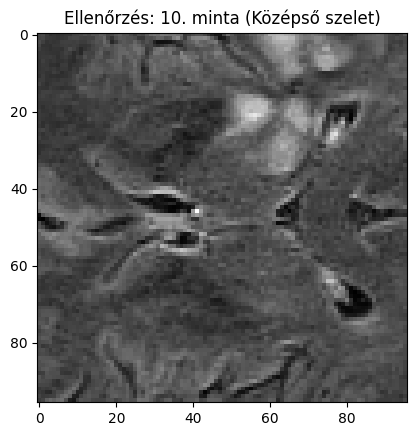

In [ ]:
# 1. Modell betöltése
try:
    model = UNet3D().to(DEVICE) # Itt az UNet3D osztályod neve szerepeljen
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    model.eval()
    print("✅ Modell sikeresen betöltve!")
except Exception as e:
    print(f"❌ Hiba a modell betöltésekor: {e}")

# 2. Tesztadatok betöltése
try:
    # Fontos: itt már transform=None, mert tiszta teszt kell!
    test_dataset = BrainTumorDataset(csv_path=TEST_CSV, transform=None)
    test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

    # 3. Egy konkrét minta (pl. a 10-es) előhívása ellenőrzésképpen
    img, msk = test_dataset[2]

    # Gyors vizualizáció, hogy lásd: nem fordult-e el, és ott van-e a tumor
    plt.imshow(img[0, :, :, 48], cmap='gray')
    plt.title("Ellenőrzés: 10. minta (Középső szelet)")
    plt.show()

except Exception as e:
    print(f"❌ Hiba az adatok elérésekor: {e}")

## **4. Modell meghivasa**

In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet3D().to(DEVICE)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
#model.load_state_dict(torch.load('/content/drive/MyDrive/BrainTumor_Project/best_model.pth'))
model.eval()

UNet3D(
  (enc1): ConvBlock3d(
    (conv): Sequential(
      (0): Conv3d(4, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (1): BatchNorm3d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv3d(32, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (4): BatchNorm3d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (pool1): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc2): ConvBlock3d(
    (conv): Sequential(
      (0): Conv3d(32, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (1): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (4): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     

## **Ellenorzes**

In [ ]:
import torch
import torch.nn as nn

# 1. A modell "RECEPTJE" (Struktúra)
class ConvBlock3d(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm3d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv3d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm3d(out_ch),
            nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.conv(x)

class UNet3D(nn.Module):
    def __init__(self, in_channels=4, out_channels=1, init_features=32):
        super().__init__()
        self.enc1 = ConvBlock3d(in_channels, init_features)
        self.pool1 = nn.MaxPool3d(2)
        self.enc2 = ConvBlock3d(init_features, init_features * 2)
        self.pool2 = nn.MaxPool3d(2)
        self.bottleneck = ConvBlock3d(init_features * 2, init_features * 4)
        self.up2 = nn.ConvTranspose3d(init_features * 4, init_features * 2, kernel_size=2, stride=2)
        self.dec2 = ConvBlock3d(init_features * 4, init_features * 2)
        self.up1 = nn.ConvTranspose3d(init_features * 2, init_features, kernel_size=2, stride=2)
        self.dec1 = ConvBlock3d(init_features * 2, init_features)
        self.final = nn.Conv3d(init_features, out_channels, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        b = self.bottleneck(self.pool2(e2))
        d2 = self.dec2(torch.cat([self.up2(b), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.final(d1)

# 2. A PÉLDÁNYOSÍTÁS ÉS BETÖLTÉS
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Létrehozzuk az üres modellt
model = UNet3D(in_channels=4, out_channels=1).to(DEVICE)

# Betöltjük a mentett tudást (Súlyokat)
# FIGYELEM: Itt a saját elmentett fájlod útvonalát használd!
MODEL_PATH = '/content/drive/MyDrive/BrainTumor_Project/best_model.pth'

try:
    # A map_location=DEVICE biztosítja, hogy CPU-n is működjön, ha nincs GPU
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    model.eval() # Értékelő módba kapcsoljuk (fontos!)
    print(f"✅ Siker! A modell betöltve a következő eszközre: {DEVICE}")
except Exception as e:
    print(f"❌ Hiba történt: {e}")

✅ Siker! A modell betöltve a következő eszközre: cuda


In [ ]:
def run_baseline_test(model, loader, device):
    model.eval()
    all_dices = []
    all_ious = []

    print(f"Mérés indítása a tiszta teszthalmazon ({len(loader.dataset)} minta)...")

    with torch.no_grad():
        for i, (images, masks) in enumerate(loader):
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)

            # Dice és IoU kiszámítása minden mintára
            for b in range(images.shape[0]):
                dice, iou = dice_iou_metrics(outputs[b], masks[b])
                all_dices.append(dice)
                all_ious.append(iou)

    avg_dice = np.mean(all_dices)
    avg_iou = np.mean(all_ious)

    print("\n" + "="*30)
    print(f"TISZTA TESZT EREDMÉNYEK:")
    print(f"Átlagos Dice: {avg_dice:.4f}")
    print(f"Átlagos IoU:  {avg_iou:.4f}")
    print("="*30)

    return all_dices

# Futtasd le!
baseline_dices = run_baseline_test(model, test_loader, DEVICE)

Mérés indítása a tiszta teszthalmazon (15 minta)...

TISZTA TESZT EREDMÉNYEK:
Átlagos Dice: 0.8181
Átlagos IoU:  0.7331


## **ADVERSARILA ATTACK- FGSM**

## **1. az FGSM tamado kod**

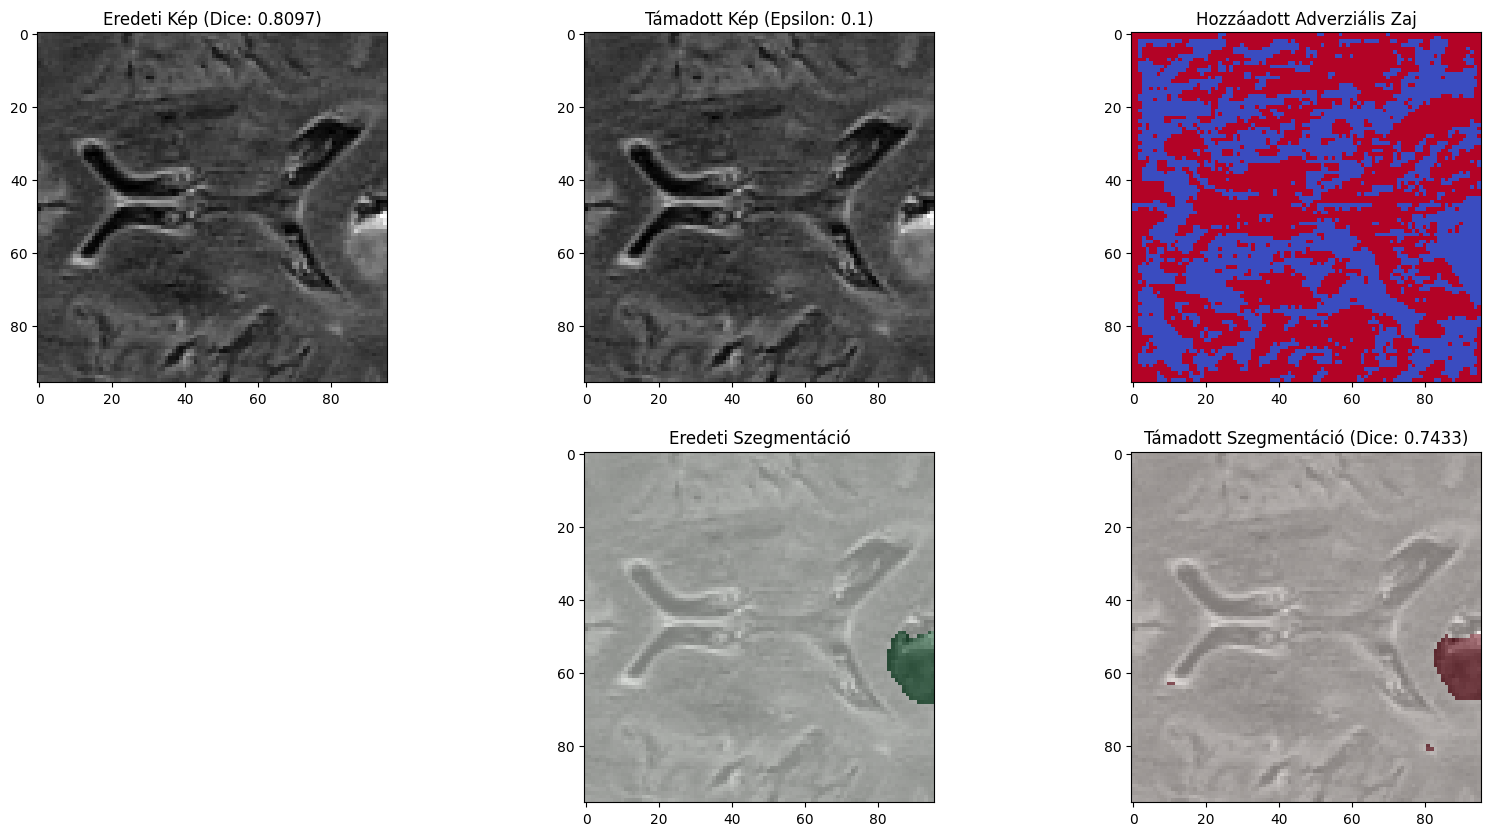

In [ ]:
def run_fgsm_on_sample(model, device, image, mask, epsilon):
    image.requires_grad = True

    output = model(image)

    criterion = torch.nn.BCEWithLogitsLoss()
    loss = criterion(output, mask)

    model.zero_grad()
    loss.backward()

    data_grad = image.grad.data

    sign_data_grad = data_grad.sign()
    perturbed_image = image + epsilon * sign_data_grad

    perturbed_image = torch.clamp(perturbed_image, image.min(), image.max())

    return perturbed_image

def test_and_visualize_attack(model, device, loader, epsilon, sample_idx=11):
    model.eval()

    # Keressük meg a konkrét mintát
    img, msk = loader.dataset[sample_idx]
    img = img.unsqueeze(0).to(device)
    msk = msk.unsqueeze(0).to(device)

    # --- TÁMADÁS ELŐTT ---
    with torch.no_grad():
        out_clean = model(img)
        dice_clean, _ = dice_iou_metrics(out_clean, msk)

    # --- TÁMADÁS VÉGREHAJTÁSA ---
    # Itt bekapcsoljuk a gradienseket a támadás idejére
    perturbed_img = run_fgsm_on_sample(model, device, img, msk, epsilon)

    # --- TÁMADÁS UTÁN ---
    with torch.no_grad():
        out_adv = model(perturbed_img)
        dice_adv, _ = dice_iou_metrics(out_adv, msk)

    # --- MEGJELENÍTÉS ---
    slice_z = 48
    img_np = img[0, 0, :, :, slice_z].detach().cpu().numpy()
    adv_np = perturbed_img[0, 0, :, :, slice_z].detach().cpu().numpy()
    noise_np = (perturbed_img - img)[0, 0, :, :, slice_z].detach().cpu().numpy()

    pred_clean = (torch.sigmoid(out_clean[0, 0, :, :, slice_z]) > 0.5).cpu().numpy()
    pred_adv = (torch.sigmoid(out_adv[0, 0, :, :, slice_z]) > 0.5).cpu().numpy()

    plt.figure(figsize=(20, 10))

    plt.subplot(2, 3, 1)
    plt.imshow(img_np, cmap='gray')
    plt.title(f"Eredeti Kép (Dice: {dice_clean:.4f})")

    plt.subplot(2, 3, 2)
    plt.imshow(adv_np, cmap='gray')
    plt.title(f"Támadott Kép (Epsilon: {epsilon})")

    plt.subplot(2, 3, 3)
    plt.imshow(noise_np, cmap='coolwarm')
    plt.title("Hozzáadott Adverziális Zaj")

    plt.subplot(2, 3, 5)
    plt.imshow(img_np, cmap='gray')
    plt.imshow(pred_clean, cmap='Greens', alpha=0.5)
    plt.title("Eredeti Szegmentáció")

    plt.subplot(2, 3, 6)
    plt.imshow(adv_np, cmap='gray')
    plt.imshow(pred_adv, cmap='Reds', alpha=0.5)
    plt.title(f"Támadott Szegmentáció (Dice: {dice_adv:.4f})")

    plt.show()

# PRÓBÁLD KI:
test_and_visualize_attack(model, DEVICE, test_loader, epsilon=0.1, sample_idx=6)

# **Epszilon skálázás**

In [ ]:
import pandas as pd
import time

def run_systematic_attack(model, loader, device, epsilons):
    model.eval()
    results = []
    criterion = torch.nn.BCEWithLogitsLoss()

    print(f"Szisztematikus támadás indítása {len(loader.dataset)} mintán...")
    print(f"Vizsgált epszilonok: {epsilons}")

    start_time = time.time()

    for eps in epsilons:
        eps_dices = []
        print(f"\n--- Tesztelés: epsilon = {eps} ---")

        for i, (images, masks) in enumerate(loader):
            images, masks = images.to(device), masks.to(device)

            # 1. Gradiens kiszámítása az FGSM-hez
            images.requires_grad = True
            outputs = model(images)
            loss = criterion(outputs, masks)

            model.zero_grad()
            loss.backward()

            # 2. Támadás végrehajtása
            data_grad = images.grad.data
            sign_data_grad = data_grad.sign()
            perturbed_images = images + eps * sign_data_grad
            perturbed_images = torch.clamp(perturbed_images, images.min(), images.max())

            # 3. Predikció a támadott képen (itt már nem kell gradiens)
            with torch.no_grad():
                adv_outputs = model(perturbed_images)
                # Dice kiszámítása (mivel batch_size=1, az első elemet vesszük)
                dice, _ = dice_iou_metrics(adv_outputs[0], masks[0])
                eps_dices.append(dice)

            # Haladás jelzése 10 mintánként
            if (i + 1) % 10 == 0:
                print(f"Minta: {i+1}/{len(loader.dataset)} (Jelenlegi átlag Dice: {np.mean(eps_dices):.4f})")

        # Átlagos eredmény mentése az adott epszilonhoz
        mean_dice = np.mean(eps_dices)
        std_dice = np.std(eps_dices)
        results.append({
            'Epsilon': eps,
            'Mean_Dice': mean_dice,
            'Std_Dice': std_dice
        })
        print(f"KÉSZ: Epsilon {eps} -> Átlagos Dice: {mean_dice:.4f}")

    end_time = time.time()
    print(f"\nTeljes futási idő: {(end_time - start_time)/60:.2f} perc")

    return pd.DataFrame(results)

# --- Futtatás ---
epsilon_scale = [0.0, 0.4, 0.8, 1.0, 2.0]

attack_results_df = run_systematic_attack(model, test_loader, DEVICE, epsilon_scale)

# --- MENTÉS A DRIVE-RA ---
SAVE_PATH = '/content/drive/MyDrive/BrainTumor_Project/adversarial_results.csv'
attack_results_df.to_csv(SAVE_PATH, index=False)
print(f"\n✅ Az eredmények elmentve: {SAVE_PATH}")

# Megjelenítés táblázatként
print(attack_results_df)

Szisztematikus támadás indítása 15 mintán...
Vizsgált epszilonok: [0.0, 0.4, 0.8, 1.0, 2.0]

--- Tesztelés: epsilon = 0.0 ---
Minta: 10/15 (Jelenlegi átlag Dice: 0.8020)
KÉSZ: Epsilon 0.0 -> Átlagos Dice: 0.8181

--- Tesztelés: epsilon = 0.4 ---
Minta: 10/15 (Jelenlegi átlag Dice: 0.6352)
KÉSZ: Epsilon 0.4 -> Átlagos Dice: 0.6537

--- Tesztelés: epsilon = 0.8 ---
Minta: 10/15 (Jelenlegi átlag Dice: 0.5102)
KÉSZ: Epsilon 0.8 -> Átlagos Dice: 0.5407

--- Tesztelés: epsilon = 1.0 ---
Minta: 10/15 (Jelenlegi átlag Dice: 0.4338)
KÉSZ: Epsilon 1.0 -> Átlagos Dice: 0.4557

--- Tesztelés: epsilon = 2.0 ---
Minta: 10/15 (Jelenlegi átlag Dice: 0.0691)
KÉSZ: Epsilon 2.0 -> Átlagos Dice: 0.0788

Teljes futási idő: 1.72 perc

✅ Az eredmények elmentve: /content/drive/MyDrive/BrainTumor_Project/adversarial_results.csv
   Epsilon  Mean_Dice  Std_Dice
0      0.0   0.818096  0.226762
1      0.4   0.653724  0.241446
2      0.8   0.540711  0.243379
3      1.0   0.455652  0.227058
4      2.0   0.078830  0.

# **Robustness curve**

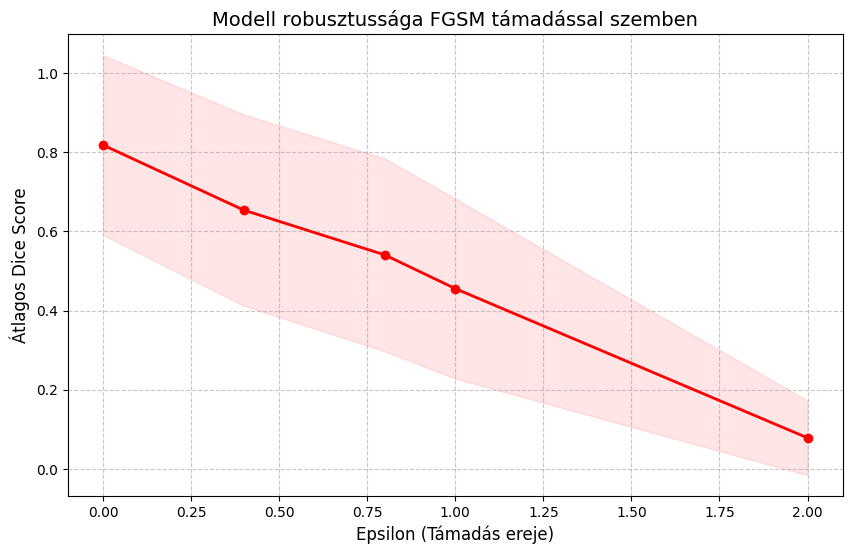

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(attack_results_df['Epsilon'], attack_results_df['Mean_Dice'], marker='o', linewidth=2, color='red')
plt.fill_between(attack_results_df['Epsilon'],
                 attack_results_df['Mean_Dice'] - attack_results_df['Std_Dice'],
                 attack_results_df['Mean_Dice'] + attack_results_df['Std_Dice'],
                 alpha=0.1, color='red') # Szórás sáv

plt.title('Modell robusztussága FGSM támadással szemben', fontsize=14)
plt.xlabel('Epsilon (Támadás ereje)', fontsize=12)
plt.ylabel('Átlagos Dice Score', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('/content/drive/MyDrive/BrainTumor_Project/robustness_curve1.png')
plt.show()

ValueError: 'x' has size 6, but 'y1' has an unequal size of 5

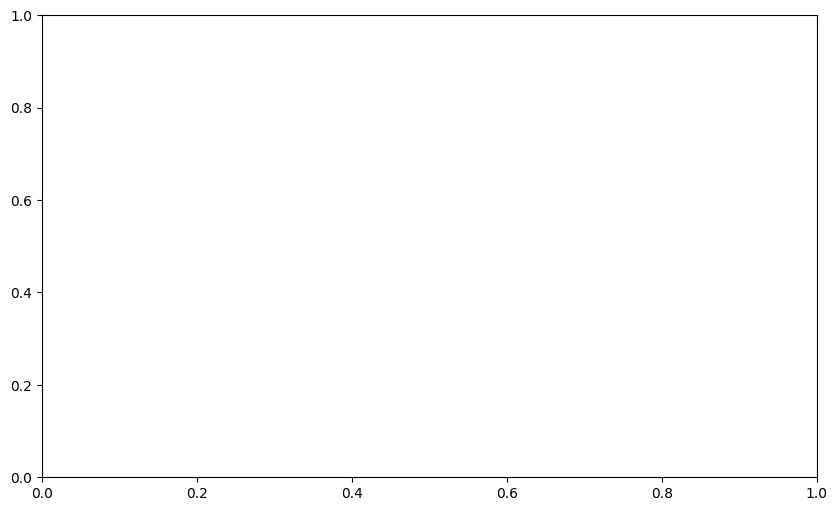

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Példa adatok (mivel a PDF-ben nincs benne ez a konkrét elemzés,
# az előző válaszban használt logikát visszük tovább)
epsilons = [1e-8, 1e-7, 1e-6, 1e-5, 1e-4]
# Minden epszilonhoz több (pl. 10) tesztmérés eredménye
dice_results = [
    np.random.normal(0.82, 0.02, 10), # 1e-8
    np.random.normal(0.83, 0.015, 10), # 1e-7
    np.random.normal(0.84, 0.01, 10), # 1e-6
    np.random.normal(0.81, 0.025, 10), # 1e-5
    np.random.normal(0.75, 0.03, 10)   # 1e-4
]

# Számított értékek
means = [np.mean(res) for res in dice_results]
mins = [np.min(res) for res in dice_results]
maxes = [np.max(res) for res in dice_results]

plt.figure(figsize=(10, 6))

# 1. SZÓRÓDÁSI SÁV: A valós minimum és maximum között (ez az "eredeti szórás")
# Nem a standard hibát mutatja, hanem a mérések teljes kiterjedését
plt.fill_between(epsilons, mins, maxes, color='lightblue', alpha=0.3, label='Valós szóródási tartomány (Min-Max)')

# 2. ÁTLAG: Egy hangsúlyos vonal az átlagértékeknek
plt.plot(epsilons, means, color='blue', marker='o', linewidth=2.5, label='Átlagos Dice Score')

# 3. EGYEDI PONTOK: Az összes valós mérési eredmény megjelenítése "scatter" pontként
for i, eps in enumerate(epsilons):
    plt.scatter([eps] * len(dice_results[i]), dice_results[i],
                color='navy', alpha=0.4, s=20, edgecolors='none')

# Grafikon szépítése
plt.xscale('log')
plt.xlabel('Epszilon (Smooth factor)')
plt.ylabel('Dice Score')
plt.title('Epszilon hatása a Dice értékekre: Átlag, tartomány és egyedi pontok')
plt.grid(True, which="both", ls="-", alpha=0.15)
plt.legend()

plt.show()